<a href="https://colab.research.google.com/github/revengsairany-bot/README.md/blob/main/Customer_Churn_%26_Retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Analysis

## Project Overview

This project analyzes customer churn patterns for a telecommunications company using customer demographic, service, contract, tenure, and billing data.

The goal of this analysis is to identify which customers are most likely to churn, understand the factors associated with customer loss, and estimate the revenue impact of churn.

### Business Questions

- Which customer segments have the highest churn rates?
- How does customer tenure relate to churn?
- Which customers represent the highest churn risk?
- How much monthly revenue is associated with high-risk customers?
- What actions could the company take to improve customer retention?

### Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab


In [1]:
import pandas as pd

df = pd.read_csv("telco_customer_churn.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Data Cleaning & Preparation

The dataset was reviewed for missing values, data types, and fields requiring transformation before analysis. All core analytical fields were complete, while Churn Reason contained missing values for customers who had not churned. These missing values were retained because they are expected for non-churned customers. Numeric fields such as Tenure Months and Monthly Charges were retained in numeric format for analysis.

In [4]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


## Exploratory Data Analysis

This section examines customer churn patterns across tenure, customer segments, and revenue. The analysis focuses on identifying high-risk customers and quantifying the potential revenue impact of customer churn.

In [5]:
total_customers = len(df)
total_churned = df["Churn Value"].sum()

overall_churn_rate = total_churned / total_customers * 100

print("Total customers:", total_customers)
print("Customers who churned:", total_churned)
print("Overall churn rate:", round(overall_churn_rate, 2), "%")

Total customers: 7043
Customers who churned: 1869
Overall churn rate: 26.54 %


### Overall Churn Rate

The dataset contains 7,043 customers, of whom 1,869 have churned. This results in an overall churn rate of 26.54%, providing a baseline for comparing churn across customer segments and tenure groups.

In [6]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


### Churn by Customer Tenure

Customer tenure was analyzed to determine whether churn risk changes throughout the customer lifecycle. Customers were grouped into five tenure ranges and their churn rates were compared.

In [7]:
# Group customers by tenure
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = df.groupby("Tenure Group", observed=False)["Churn Value"].mean() * 100

tenure_churn

,Churn Value
Tenure Group,
0-6 months,53.333333
7-12 months,35.886525
13-24 months,28.710938
25-48 months,20.388959
49-72 months,9.513176


##Key Insight
Customers with shorter tenure have substantially higher churn rates than long-tenure customers. The highest churn rate occurs among customers in their first six months, indicating that the early customer lifecycle is a critical period for retention. Churn decreases as customer tenure increases, suggesting that customers who remain longer are more likely to stay with the company.

In [9]:
import pandas as pd

url = "https://raw.githubusercontent.com/revengsairany-bot/customer-churn-retention-analysis/main/data/telco_customer_churn.csv"

df = pd.read_csv(url)

churned_monthly_charges = df[df["Churn Label"] == "Yes"]["Monthly Charges"].sum()
average_churned_charge = df[df["Churn Label"] == "Yes"]["Monthly Charges"].mean()

print("Monthly charges associated with churned customers:", churned_monthly_charges)
print("Average monthly charge of churned customers:", average_churned_charge)

Monthly charges associated with churned customers: 139130.85
Average monthly charge of churned customers: 74.44133226324237


In [10]:
contract_churn = df.groupby("Contract")["Churn Value"].mean() * 100

contract_churn

,Churn Value
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [11]:
df.groupby("Internet Service")["Churn Value"].mean().sort_values(ascending=False) * 100

,Churn Value
Internet Service,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


In [12]:
df.groupby(["Contract", "Internet Service"])["Churn Value"].mean().unstack() * 100

Internet Service,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.215863,54.605263,18.893130
One year,9.298246,19.294991,2.472527
Two year,1.910828,7.226107,0.783699


In [13]:
high_risk_segment = df[
    (df["Contract"] == "Month-to-month") &
    (df["Internet Service"] == "Fiber optic")
]

print("Customers in high-risk segment:", len(high_risk_segment))
print("Customers who churned:", high_risk_segment["Churn Value"].sum())
print("Churn rate:", high_risk_segment["Churn Value"].mean() * 100)

Customers in high-risk segment: 2128
Customers who churned: 1162
Churn rate: 54.60526315789473


In [14]:
total_customers = len(df)
total_churned = df["Churn Value"].sum()

segment_customers = len(high_risk_segment)
segment_churned = high_risk_segment["Churn Value"].sum()

print("Share of all customers:", round(segment_customers / total_customers * 100, 2), "%")
print("Share of all churned customers:", round(segment_churned / total_churned * 100, 2), "%")

Share of all customers: 30.21 %
Share of all churned customers: 62.17 %


In [15]:
churned_segment = high_risk_segment[
    high_risk_segment["Churn Value"] == 1
]

total_lost_monthly_revenue = churned_segment["Monthly Charges"].sum()

print(
    "Monthly revenue associated with churned segment:",
    round(total_lost_monthly_revenue, 2)
)

print(
    "Average monthly charge per churned customer:",
    round(churned_segment["Monthly Charges"].mean(), 2)
)


Monthly revenue associated with churned segment: 100482.0
Average monthly charge per churned customer: 86.47


In [16]:
print("Average monthly charge - all customers:",
      round(df["Monthly Charges"].mean(), 2))

print("Average monthly charge - churned customers:",
      round(df[df["Churn Value"] == 1]["Monthly Charges"].mean(), 2))

print("Average monthly charge - churned month-to-month fiber:",
      round(churned_segment["Monthly Charges"].mean(), 2))

Average monthly charge - all customers: 64.76
Average monthly charge - churned customers: 74.44
Average monthly charge - churned month-to-month fiber: 86.47


In [17]:
overall_avg = df["Monthly Charges"].mean()
segment_avg = churned_segment["Monthly Charges"].mean()

difference = segment_avg - overall_avg
percent_higher = (difference / overall_avg) * 100

print("Average charge difference: $", round(difference, 2))
print("High-risk segment is", round(percent_higher, 2), "% higher than overall average")

Average charge difference: $ 21.71
High-risk segment is 33.53 % higher than overall average


In [18]:
total_monthly_revenue = df["Monthly Charges"].sum()
segment_monthly_revenue = high_risk_segment["Monthly Charges"].sum()

revenue_share = (segment_monthly_revenue / total_monthly_revenue) * 100

print("Total monthly revenue:", round(total_monthly_revenue, 2))
print("High-risk segment monthly revenue:", round(segment_monthly_revenue, 2))
print("High-risk segment share of monthly revenue:", round(revenue_share, 2), "%")

Total monthly revenue: 456116.6
High-risk segment monthly revenue: 185181.1
High-risk segment share of monthly revenue: 40.6 %


In [19]:
churned_segment = high_risk_segment[
    high_risk_segment["Churn Value"] == 1
]

lost_monthly_revenue = churned_segment["Monthly Charges"].sum()

print(
    "Monthly revenue lost from churned high-risk customers:",
    round(lost_monthly_revenue, 2)
)

Monthly revenue lost from churned high-risk customers: 100482.0


In [20]:
churned_revenue_share = (
    lost_monthly_revenue / segment_monthly_revenue
) * 100

print(
    "Share of high-risk segment revenue lost to churn:",
    round(churned_revenue_share, 2),
    "%"
)

Share of high-risk segment revenue lost to churn: 54.26 %


In [21]:
high_risk_segment["Tenure Months"].describe()

,Tenure Months
count,2128.000000
mean,21.554981
std,18.941719
min,1.000000
25%,5.000000
50%,16.000000
75%,34.000000
max,72.000000


In [22]:
tenure_churn = df.groupby(
    pd.cut(
        df["Tenure Months"],
        bins=[0, 6, 12, 24, 48, 72],
        labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"]
    )
)["Churn Value"].mean() * 100

tenure_churn

/tmp/ipykernel_5486/4055747515.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby(


,Churn Value
Tenure Months,
0-6 months,53.333333
7-12 months,35.886525
13-24 months,28.710938
25-48 months,20.388959
49-72 months,9.513176


In [23]:
tenure_churn = df.groupby(
    pd.cut(
        df["Tenure Months"],
        bins=[0, 6, 12, 24, 48, 72],
        labels=["0-6 months", "7-12 months", "13-24 months",
                "25-48 months", "49-72 months"]
    ),
    observed=False
)["Churn Value"].mean() * 100

In [24]:
high_risk_tenure_churn = high_risk_segment.groupby(
    pd.cut(
        high_risk_segment["Tenure Months"],
        bins=[0, 6, 12, 24, 48, 72],
        labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"]
    )
)["Churn Value"].mean() * 100

high_risk_tenure_churn

/tmp/ipykernel_5486/2465121567.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_risk_tenure_churn = high_risk_segment.groupby(


,Churn Value
Tenure Months,
0-6 months,74.151858
7-12 months,61.952862
13-24 months,50.588235
25-48 months,43.378119
49-72 months,29.323308


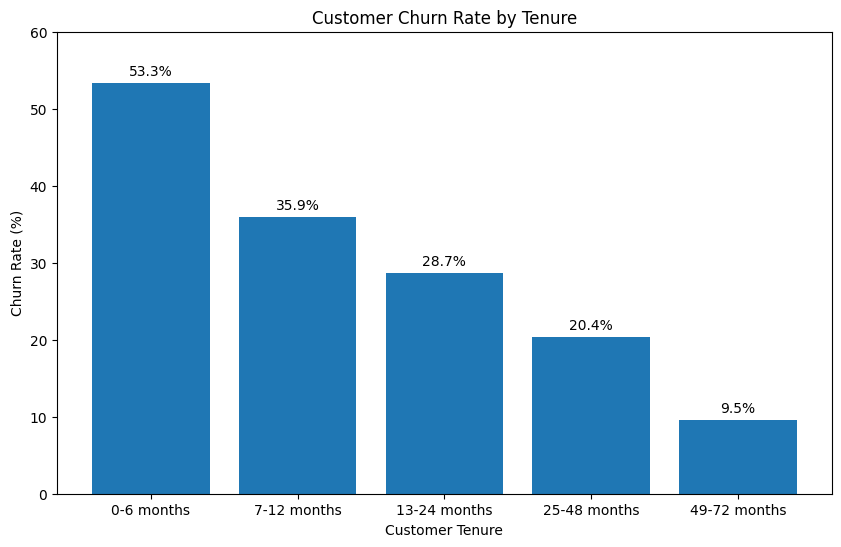

In [25]:
import matplotlib.pyplot as plt

tenure_labels = tenure_churn.index.astype(str)
churn_rates = tenure_churn.values

plt.figure(figsize=(10, 6))

bars = plt.bar(tenure_labels, churn_rates)

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 60)

for bar, rate in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center"
    )

plt.show()

Key Insight: Customer Churn by Tenure

Customer churn is highest among newer customers and decreases consistently as tenure increases. Customers with 0–6 months of tenure have the highest churn rate at 53.3%, while customers with 49–72 months of tenure have the lowest rate at 9.5%. This indicates that the early stages of the customer lifecycle are a critical period for retention.

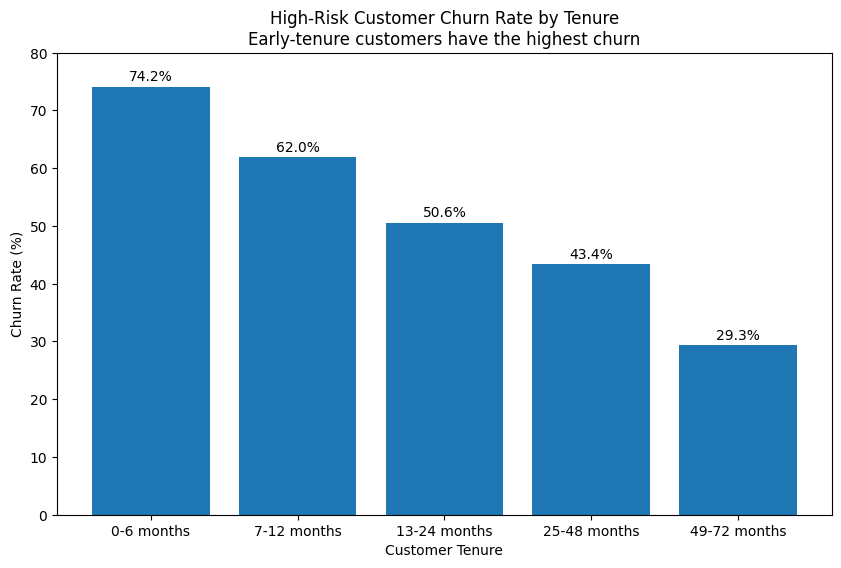

In [26]:
import matplotlib.pyplot as plt

tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

churn_rates = [
    74.15,
    61.95,
    50.59,
    43.38,
    29.32
]

plt.figure(figsize=(10, 6))

bars = plt.bar(tenure_labels, churn_rates)

plt.title(
    "High-Risk Customer Churn Rate by Tenure\n"
    "Early-tenure customers have the highest churn"
)

plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 80)

for bar, rate in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center"
    )

plt.show()

Key Insight: High-Risk Customer Tenure

Churn is highest among high-risk customers during their first six months, at 74.2%, and decreases as tenure increases. Even among customers who remain in the high-risk segment, newer customers are substantially more likely to churn than long-tenured customers. This suggests that the first year is a particularly important period for retention efforts within this segment.

High-Risk Customer Segment

In [27]:
# High-risk customer segment:
# Month-to-month contract + Fiber optic internet

high_risk_segment = df[
    (df["Contract"] == "Month-to-month") &
    (df["Internet Service"] == "Fiber optic")
]

# Calculate key metrics
high_risk_customers = len(high_risk_segment)

high_risk_churn_rate = (
    high_risk_segment["Churn Value"].mean() * 100
)

high_risk_churned = (
    high_risk_segment["Churn Value"].sum()
)

print("High-risk customer segment")
print("--------------------------")
print("Customers:", high_risk_customers)
print("Customers who churned:", high_risk_churned)
print("Churn rate:", round(high_risk_churn_rate, 2), "%")

High-risk customer segment
--------------------------
Customers: 2128
Customers who churned: 1162
Churn rate: 54.61 %


In [28]:
# Compare the high-risk segment with the overall customer base

total_customers = len(df)
total_churned = df["Churn Value"].sum()

segment_customer_share = (
    high_risk_customers / total_customers * 100
)

segment_churn_share = (
    high_risk_churned / total_churned * 100
)

print("Share of all customers:",
      round(segment_customer_share, 2), "%")

print("Share of all churned customers:",
      round(segment_churn_share, 2), "%")


Share of all customers: 30.21 %
Share of all churned customers: 62.17 %


In [29]:
# Calculate monthly revenue associated with the high-risk segment

total_monthly_revenue = df["Monthly Charges"].sum()

segment_monthly_revenue = (
    high_risk_segment["Monthly Charges"].sum()
)

revenue_share = (
    segment_monthly_revenue / total_monthly_revenue * 100
)

print("Total monthly revenue:",
      round(total_monthly_revenue, 2))

print("High-risk segment monthly revenue:",
      round(segment_monthly_revenue, 2))

print("High-risk segment share of monthly revenue:",
      round(revenue_share, 2), "%")

Total monthly revenue: 456116.6
High-risk segment monthly revenue: 185181.1
High-risk segment share of monthly revenue: 40.6 %


In [30]:
# Calculate revenue lost from churned high-risk customers

churned_segment = high_risk_segment[
    high_risk_segment["Churn Value"] == 1
]

lost_monthly_revenue = (
    churned_segment["Monthly Charges"].sum()
)

churned_revenue_share = (
    lost_monthly_revenue / segment_monthly_revenue
) * 100

print(
    "Monthly revenue lost from churned high-risk customers:",
    round(lost_monthly_revenue, 2)
)

print(
    "Share of high-risk segment revenue lost to churn:",
    round(churned_revenue_share, 2),
    "%"
)

Monthly revenue lost from churned high-risk customers: 100482.0
Share of high-risk segment revenue lost to churn: 54.26 %


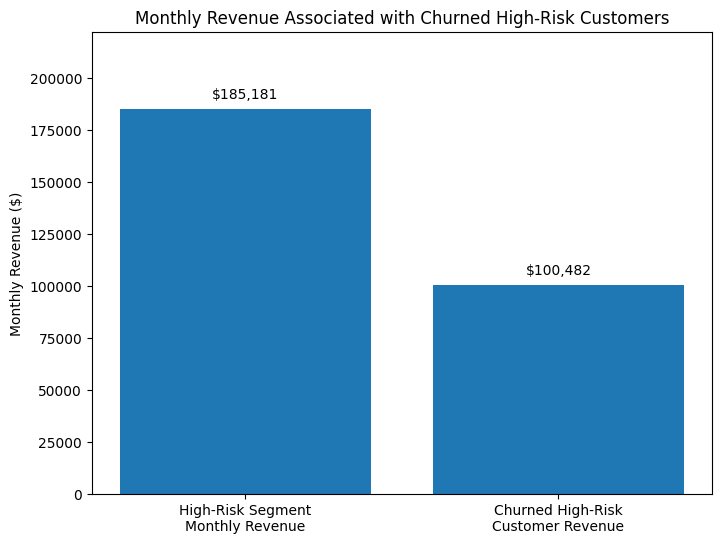

In [31]:
plt.figure(figsize=(8, 6))

labels = [
    "High-Risk Segment\nMonthly Revenue",
    "Churned High-Risk\nCustomer Revenue"
]

values = [
    segment_monthly_revenue,
    lost_monthly_revenue
]

bars = plt.bar(labels, values)

plt.title("Monthly Revenue Associated with Churned High-Risk Customers")
plt.ylabel("Monthly Revenue ($)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"${value:,.0f}",
        ha="center"
    )

plt.ylim(0, max(values) * 1.2)

plt.show()

Key Insight: Customer Churn by Tenure

Customer churn is highest among newer customers and decreases consistently as tenure increases. Customers with 0–6 months of tenure have the highest churn rate at 53.3%, while customers with 49–72 months of tenure have the lowest rate at 9.5%. This indicates that the early stages of the customer lifecycle are a critical period for retention.

## Business Recommendations

### 1. Focus Retention Efforts on Early-Tenure Customers

Within the high-risk customer segment, customers in their first 6 months have the highest churn rate at 74.2%. This suggests that the early customer experience is a critical period for retention. The company should consider onboarding programs, early check-ins, and targeted retention offers during the first several months.

### 2. Prioritize the High-Risk Customer Segment

The high-risk segment contains 2,128 customers and accounts for 62.17% of all churned customers while representing 30.21% of the total customer base. This makes the segment an important target for proactive retention efforts.

### 3. Protect Revenue at Risk

The high-risk segment generates approximately 185,181 in monthly revenue, with 100,482 in monthly charges associated with customers who have churned. Retention efforts focused on this segment could help reduce customer loss and protect recurring revenue.

## Project Summary

This analysis identified customer churn patterns and highlighted a high-risk customer segment. Overall churn is highest among customers with 0–6 months of tenure at 53.3%, while churn within the high-risk segment reaches 74.2% during the first 6 months.

The high-risk segment contains 2,128 customers and represents 30.21% of the customer base while accounting for 62.17% of all churned customers. This segment also generates approximately 185,181 dollars in monthly revenue, with 100,482 dollars associated with customers who have churned.

The analysis suggests that the company should prioritize early-tenure customer retention, proactively engage high-risk customers, and focus on protecting recurring revenue within this segment.